# CBG Panel B - Development Notebook

**Objective**: build the focal neocortical-injury diffusion panel as a standalone, executable notebook.

## Workflow
1. Load the focal source tier and atlas geometry.
2. Register the focal ROI to a coronal slice at Bregma -2.0 mm.
3. Solve a steady diffusion model on the brain mask.
4. Inspect the result with a compact visualization and QC checks.
5. Export figure assets and provenance records.

## Modeling assumptions
- The source map follows the focal asset tier priority from `fetch_data.py`.
- The source is a homogeneous microvascular perfusion map inside the focal ROI.
- The solver uses a steady diffusion-decay approximation on the atlas slice.

If required inputs are missing, Cell 2 will run `fetch_data.py` once to populate `data/`.

In [1]:
# Cell 1: imports, paths, and fixed parameters
import json
import subprocess
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.path import Path as MplPath
from scipy import ndimage
from scipy.sparse import csr_matrix, lil_matrix
from scipy.sparse.linalg import spsolve
from svgpath2mpl import parse_path

FOCAL_DIR = Path('data/focal')
ATLAS_POLY = Path('data/atlas/hippocampus_polygons_Bregma-2mm.json')
OUT_DIR = Path('CBG_panel_B_outputs')
OUT_DIR.mkdir(exist_ok=True)

D_tissue = 3e-4
P_intact = 1e-4
P_open = 5e-3
k_e = 0.05
C_blood = 1.0

print('Notebook initialized.')
print(f'Focal directory: {FOCAL_DIR.resolve()}')
print(f'Atlas polygons : {ATLAS_POLY.resolve()}')

Notebook initialized.
Focal directory: /Users/k2477067/Code/BBB_modelling/data/focal
Atlas polygons : /Users/k2477067/Code/BBB_modelling/data/atlas/hippocampus_polygons_Bregma-2mm.json


## Source loading and provenance

This cell checks that the focal asset files exist. If they do not, it runs `fetch_data.py` to populate the repository-local data folders.

The notebook then loads the focal source payload and the coronal atlas polygon set used for registration.

In [31]:
# Cell 2: load focal source tier and atlas metadata
def ensure_inputs():
    pdf_path = Path('data/Focal_Epilepsy_Model.pdf')
    if pdf_path.exists():
        return

    required = [FOCAL_DIR / 'focal_model_metadata.json']
    if not all(path.exists() for path in required):
        print('Required inputs missing; running fetch_data.py ...')
        result = subprocess.run([sys.executable, 'fetch_data.py'], check=False)
        print(f'fetch_data.py exit code: {result.returncode}')
    if not all(path.exists() for path in required):
        missing = [str(path) for path in required if not path.exists()]
        raise FileNotFoundError(f'Missing required inputs after fetch_data.py: {missing}')


def _load_focal_source(focal_dir=FOCAL_DIR):
    pdf_path = Path('data/Focal_Epilepsy_Model.pdf')
    if pdf_path.exists():
        return {
            'source_tier': 'pdf-panel-e',
            'pdf_path': str(pdf_path),
            'pdf_page_index': 3,
            # Shift left crop boundary rightward to remove the persistent panel-edge artifact.
            'pdf_crop_box': [455, 835, 715, 1035],
            'flip_ud': True,
            'flip_lr': False,
            # Tunable preprocessing/alignment parameters.
            'tissue_threshold_sum': 20,
            'crop_pad_px': 8,
            'preserve_aspect': True,
            'align_shift_x_px': 0,
            'align_shift_y_px': 0,
            'align_scale_x': 1.0,
            'align_scale_y': 1.0,
            'auto_align_to_brain': True,
            'auto_search_shift_px': 12,
            'auto_search_scale_offsets': [-0.10, 0.0, 0.10],
            'smooth_sigma_atlas': 1.2,
            'edge_exclusion_px': 5,
            'left_edge_artifact_guard': True,
            'left_edge_guard_zone_frac': 0.15,
            'left_edge_guard_ratio': 2.2,
            'focal_percentile': 90,
            'paper_meta': {
                'title': 'Neuronal circuits sustaining neocortical-injury-induced status epilepticus',
                'doi': '10.1016/j.nbd.2022.105633',
                'journal': 'Neurobiology of Disease',
                'year': 2022,
                'source': 'Focal_Epilepsy_Model.pdf',
                'panel': 'Figure 1 Panel E (cFos, AP -2.4)',
            },
        }

    meta = {}
    meta_path = focal_dir / 'focal_model_metadata.json'
    if meta_path.exists():
        with open(meta_path) as f:
            meta = json.load(f)

    candidates = [
        focal_dir / 'focal_raw_pointer.json',
        focal_dir / 'focal_ictal_roi_figure_derived.json',
        focal_dir / 'focal_ictal_roi_synthetic.json',
    ]
    for path in candidates:
        if path.exists():
            with open(path) as f:
                payload = json.load(f)
            payload['paper_meta'] = meta
            payload.setdefault('source_tier', payload.get('source_tier', 'synthetic'))
            payload.setdefault('tissue_threshold_sum', 20)
            payload.setdefault('crop_pad_px', 8)
            payload.setdefault('preserve_aspect', True)
            payload.setdefault('align_shift_x_px', 0)
            payload.setdefault('align_shift_y_px', 0)
            payload.setdefault('align_scale_x', 1.0)
            payload.setdefault('align_scale_y', 1.0)
            payload.setdefault('auto_align_to_brain', True)
            payload.setdefault('auto_search_shift_px', 12)
            payload.setdefault('auto_search_scale_offsets', [-0.10, 0.0, 0.10])
            payload.setdefault('smooth_sigma_atlas', 1.2)
            payload.setdefault('edge_exclusion_px', 5)
            payload.setdefault('left_edge_artifact_guard', True)
            payload.setdefault('left_edge_guard_zone_frac', 0.15)
            payload.setdefault('left_edge_guard_ratio', 2.2)
            payload.setdefault('focal_percentile', 90)
            return payload
    raise FileNotFoundError('No focal source asset found under data/focal')


def _path_to_subpaths(mp):
    verts = np.asarray(mp.vertices, dtype=float)
    codes = np.asarray(mp.codes) if mp.codes is not None else None
    if verts.shape[0] < 3:
        return []
    if codes is None:
        return [verts]

    MOVETO = 1
    starts = np.where(codes == MOVETO)[0]
    if len(starts) == 0:
        return [verts]

    segments = []
    for i, s in enumerate(starts):
        e = starts[i + 1] if i + 1 < len(starts) else len(verts)
        seg = verts[s:e]
        if seg.shape[0] >= 3:
            segments.append(seg)
    return segments


def _outline_from_binary_mask(mask, x_span=(-4.0, 4.0), y_span=(-2.2, 2.2)):
    mask = ndimage.binary_fill_holes(mask)
    mask = ndimage.binary_opening(mask, iterations=1)
    mask = ndimage.binary_closing(mask, iterations=2)

    labels, n = ndimage.label(mask)
    if n == 0:
        raise RuntimeError('No connected component found in atlas mask')
    sizes = ndimage.sum(mask, labels, range(1, n + 1))
    keep = labels == (np.argmax(sizes) + 1)

    fig, ax = plt.subplots(figsize=(2, 2))
    cs = ax.contour(keep.astype(float), levels=[0.5])
    plt.close(fig)
    segs = cs.allsegs[0]
    if len(segs) == 0:
        raise RuntimeError('No contour extracted from atlas mask')
    outline = max(segs, key=lambda s: s.shape[0])

    x = outline[:, 0]
    y = outline[:, 1]
    x_mm = (x - x.min()) / max(x.max() - x.min(), 1e-6) * (x_span[1] - x_span[0]) + x_span[0]
    y_mm = y_span[1] - (y - y.min()) / max(y.max() - y.min(), 1e-6) * (y_span[1] - y_span[0])
    return np.column_stack([x_mm, y_mm])


def _load_allen_outline_raster(atlas_image_id=100960065):
    import io
    import urllib.request
    from PIL import Image

    # Use Allen's atlas raster image; this often gives a cleaner whole-brain boundary than SVG labels.
    url = f'https://api.brain-map.org/api/v2/atlas_image_download/{atlas_image_id}?annotation=true'
    raw = urllib.request.urlopen(url, timeout=30).read()
    img = Image.open(io.BytesIO(raw)).convert('RGB')
    arr = np.asarray(img)

    # Atlas image background is near-white; brain tissue/labels are darker and/or colored.
    gray = arr.mean(axis=2)
    sat = arr.max(axis=2) - arr.min(axis=2)
    mask = (gray < 245) | (sat > 10)

    return _outline_from_binary_mask(mask)


def _load_allen_outline_svg(atlas_image_id=100960065):
    import urllib.request
    import xml.etree.ElementTree as ET
    from PIL import Image, ImageDraw

    url = f'https://api.brain-map.org/api/v2/svg_download/{atlas_image_id}'
    xml_txt = urllib.request.urlopen(url, timeout=30).read().decode('utf-8', errors='ignore')
    root = ET.fromstring(xml_txt)

    subpaths = []
    for node in root.iter():
        if node.tag.endswith('path'):
            d = node.attrib.get('d', '')
            if not d:
                continue
            try:
                mp = parse_path(d)
                for seg in _path_to_subpaths(mp):
                    if seg.shape[0] >= 20 and np.isfinite(seg).all():
                        subpaths.append(seg)
            except Exception:
                continue

    if len(subpaths) == 0:
        raise RuntimeError('Allen SVG had no usable path contours')

    all_pts = np.vstack(subpaths)
    xmin, ymin = all_pts.min(axis=0)
    xmax, ymax = all_pts.max(axis=0)

    W, H = 1400, 1000
    sx = (W - 1) / max(xmax - xmin, 1e-6)
    sy = (H - 1) / max(ymax - ymin, 1e-6)

    img = Image.new('L', (W, H), 0)
    draw = ImageDraw.Draw(img)
    for seg in subpaths:
        p = np.empty_like(seg)
        p[:, 0] = (seg[:, 0] - xmin) * sx
        p[:, 1] = (seg[:, 1] - ymin) * sy
        draw.polygon([tuple(v) for v in p], outline=1, fill=1)

    mask = np.array(img, dtype=bool)
    return _outline_from_binary_mask(mask)


def _load_brain_outline(poly_path=ATLAS_POLY):
    # Prefer Allen raster-derived contour, then Allen SVG-derived contour, then local fallback.
    try:
        outline = _load_allen_outline_raster(atlas_image_id=100960065)
        return outline, {
            'source': 'Allen API atlas image raster',
            'atlas_image_id': 100960065,
            'endpoint': 'atlas_image_download?annotation=true',
            'bregma_mm': -2.0,
        }
    except Exception as e_raster:
        print(f'Allen raster outline unavailable, trying SVG: {type(e_raster).__name__}: {e_raster}')

    try:
        outline = _load_allen_outline_svg(atlas_image_id=100960065)
        return outline, {
            'source': 'Allen API SVG atlas image',
            'atlas_image_id': 100960065,
            'endpoint': 'svg_download',
            'bregma_mm': -2.0,
        }
    except Exception as e_svg:
        print(f'Allen SVG outline unavailable, falling back: {type(e_svg).__name__}: {e_svg}')

    if poly_path.exists():
        with open(poly_path) as f:
            payload = json.load(f)
        return np.array(payload['polygons']['brain_outline'], dtype=float), payload

    fallback_payload = {
        'source': 'embedded fallback (full coronal)',
        'bregma_mm': -2.0,
        'units': 'mm from midline (x) and dorsal-ventral depth (y)',
        'polygons': {
            'brain_outline': [
                [-4.0, 0.0], [-3.8, 0.7], [-3.4, 1.2], [-2.8, 1.6], [-2.2, 1.9],
                [-1.6, 2.05], [-1.0, 2.15], [-0.5, 2.2], [0.0, 2.22], [0.5, 2.2],
                [1.0, 2.15], [1.6, 2.05], [2.2, 1.9], [2.8, 1.6], [3.4, 1.2],
                [3.8, 0.7], [4.0, 0.0], [3.8, -0.7], [3.4, -1.2], [2.8, -1.6],
                [2.2, -1.9], [1.6, -2.05], [1.0, -2.15], [0.5, -2.2], [0.0, -2.22],
                [-0.5, -2.2], [-1.0, -2.15], [-1.6, -2.05], [-2.2, -1.9], [-2.8, -1.6],
                [-3.4, -1.2], [-3.8, -0.7], [-4.0, 0.0],
            ]
        }
    }
    return np.array(fallback_payload['polygons']['brain_outline'], dtype=float), fallback_payload


ensure_inputs()
focal_payload = _load_focal_source()
brain_outline, atlas_poly_meta = _load_brain_outline()

print('Focal source tier:', focal_payload.get('source_tier', 'unknown'))
print('Paper DOI        :', focal_payload.get('paper_meta', {}).get('doi', 'n/a'))
print('Atlas source     :', atlas_poly_meta.get('source', 'n/a'))
print('Tuning params    :', {
    'pdf_crop_box': focal_payload.get('pdf_crop_box'),
    'crop_pad_px': focal_payload.get('crop_pad_px'),
    'tissue_threshold_sum': focal_payload.get('tissue_threshold_sum'),
    'preserve_aspect': focal_payload.get('preserve_aspect'),
    'align_shift_x_px': focal_payload.get('align_shift_x_px'),
    'align_shift_y_px': focal_payload.get('align_shift_y_px'),
    'align_scale_x': focal_payload.get('align_scale_x'),
    'align_scale_y': focal_payload.get('align_scale_y'),
    'auto_align_to_brain': focal_payload.get('auto_align_to_brain'),
    'auto_search_shift_px': focal_payload.get('auto_search_shift_px'),
    'auto_search_scale_offsets': focal_payload.get('auto_search_scale_offsets'),
    'smooth_sigma_atlas': focal_payload.get('smooth_sigma_atlas'),
    'edge_exclusion_px': focal_payload.get('edge_exclusion_px'),
    'left_edge_artifact_guard': focal_payload.get('left_edge_artifact_guard'),
    'focal_percentile': focal_payload.get('focal_percentile'),
})

Focal source tier: pdf-panel-e
Paper DOI        : 10.1016/j.nbd.2022.105633
Atlas source     : Allen API atlas image raster
Tuning params    : {'pdf_crop_box': [455, 835, 715, 1035], 'crop_pad_px': 8, 'tissue_threshold_sum': 20, 'preserve_aspect': True, 'align_shift_x_px': 0, 'align_shift_y_px': 0, 'align_scale_x': 1.0, 'align_scale_y': 1.0, 'auto_align_to_brain': True, 'auto_search_shift_px': 12, 'auto_search_scale_offsets': [-0.1, 0.0, 0.1], 'smooth_sigma_atlas': 1.2, 'edge_exclusion_px': 5, 'left_edge_artifact_guard': True, 'focal_percentile': 90}


## Coronal registration grid

The focal ROI is projected onto a coronal working grid in mm coordinates. The grid is intentionally larger than the ROI so the spatial context is visible around the source field.

Grid shape            : (110, 160)
Brain coverage        : 0.552
Focal percentile      : 90.0
Edge exclusion px     : 5
Focal coverage of brain: 8.522%
Alignment fit         : {'mode': 'auto', 'score': 0.8617, 'scale_x': 0.8, 'scale_y': 0.75, 'shift_x_px': 0.0, 'shift_y_px': 0.0, 'trimmed_left_px': 5}


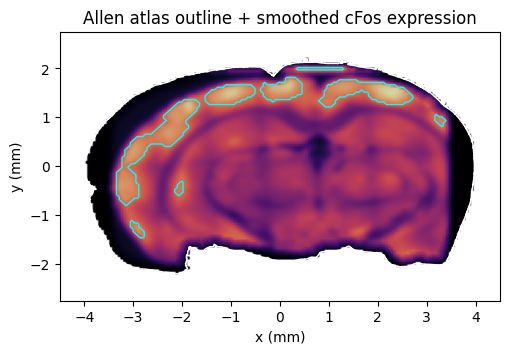

In [36]:
# Cell 3: build the coronal grid and focal mask
def _poly_mask(pts, X, Y):
    path = MplPath(np.vstack([pts, pts[0]]))
    coords = np.column_stack([X.ravel(), Y.ravel()])
    return path.contains_points(coords).reshape(X.shape)


def _render_pdf_page(pdf_path, page_index=3, scale=2.0):
    import fitz

    doc = fitz.open(str(pdf_path))
    page = doc[page_index]
    pix = page.get_pixmap(matrix=fitz.Matrix(scale, scale), alpha=False)
    image = np.frombuffer(pix.samples, dtype=np.uint8).reshape(pix.height, pix.width, pix.n)
    return image[..., :3].copy()


def _trim_left_edge_artifact(panel_rgb, payload):
    if not bool(payload.get('left_edge_artifact_guard', True)):
        return panel_rgb, 0

    zone_frac = float(payload.get('left_edge_guard_zone_frac', 0.15))
    ratio_thr = float(payload.get('left_edge_guard_ratio', 2.2))

    red = panel_rgb[..., 0].astype(float)
    ncols = red.shape[1]
    zone = max(4, int(round(ncols * zone_frac)))
    zone = min(zone, ncols)
    if zone <= 2:
        return panel_rgb, 0

    col_mean = red.mean(axis=0)
    med = float(np.median(col_mean))
    if med <= 0:
        return panel_rgb, 0

    trim = 0
    while trim < zone and col_mean[trim] > ratio_thr * med:
        trim += 1

    if trim >= 2:
        return panel_rgb[:, trim:, :], int(trim)
    return panel_rgb, 0


def _place_scaled_on_grid(img, target_shape, scale_y=1.0, scale_x=1.0, preserve_aspect=True, shift_x_px=0.0, shift_y_px=0.0):
    ty, tx = target_shape
    sy, sx = img.shape

    if preserve_aspect:
        base = min(ty / max(sy, 1), tx / max(sx, 1))
        zoom_y = max(base * scale_y, 1e-3)
        zoom_x = max(base * scale_x, 1e-3)
    else:
        zoom_y = max((ty / max(sy, 1)) * scale_y, 1e-3)
        zoom_x = max((tx / max(sx, 1)) * scale_x, 1e-3)

    rz = ndimage.zoom(img, (zoom_y, zoom_x), order=1)
    out = np.zeros((ty, tx), dtype=float)

    ry, rx = rz.shape
    y0 = (ty - ry) // 2
    x0 = (tx - rx) // 2

    src_y0 = max(0, -y0)
    src_x0 = max(0, -x0)
    dst_y0 = max(0, y0)
    dst_x0 = max(0, x0)

    h = min(ty - dst_y0, ry - src_y0)
    w = min(tx - dst_x0, rx - src_x0)
    if h > 0 and w > 0:
        out[dst_y0:dst_y0 + h, dst_x0:dst_x0 + w] = rz[src_y0:src_y0 + h, src_x0:src_x0 + w]

    if shift_x_px != 0 or shift_y_px != 0:
        out = ndimage.shift(out, shift=(shift_y_px, shift_x_px), order=1, mode='constant', cval=0.0)

    return out


def _alignment_score(src_mask, brain_mask):
    src_mask = src_mask.astype(bool)
    brain_mask = brain_mask.astype(bool)

    inter = np.logical_and(src_mask, brain_mask).sum()
    src_sum = src_mask.sum()
    brain_sum = brain_mask.sum()
    dice = (2.0 * inter) / max(src_sum + brain_sum, 1)

    outside_frac = np.logical_and(src_mask, ~brain_mask).sum() / max(src_sum, 1)
    inside_cov = inter / max(brain_sum, 1)

    return float(dice + 0.30 * inside_cov - 1.40 * outside_frac)


def _estimate_alignment(red, brain_mask, payload):
    preserve_aspect = bool(payload.get('preserve_aspect', True))
    manual = {
        'scale_x': float(payload.get('align_scale_x', 1.0)),
        'scale_y': float(payload.get('align_scale_y', 1.0)),
        'shift_x': float(payload.get('align_shift_x_px', 0.0)),
        'shift_y': float(payload.get('align_shift_y_px', 0.0)),
        'score': np.nan,
        'mode': 'manual',
    }

    if brain_mask is None or not bool(payload.get('auto_align_to_brain', True)):
        return manual

    nz = red > 0
    thr = np.percentile(red[nz], 35) if np.any(nz) else 0.0
    src_mask = red > thr
    src_mask = ndimage.binary_opening(src_mask, iterations=1)
    src_mask = ndimage.binary_closing(src_mask, iterations=2)

    shift_lim = int(payload.get('auto_search_shift_px', 12))
    offsets = payload.get('auto_search_scale_offsets', [-0.10, 0.0, 0.10])
    if not isinstance(offsets, (list, tuple)):
        offsets = [-0.10, 0.0, 0.10]

    base_scale_x = float(payload.get('align_scale_x', 1.0))
    base_scale_y = float(payload.get('align_scale_y', 1.0))
    shift_seed_x = float(payload.get('align_shift_x_px', 0.0))
    shift_seed_y = float(payload.get('align_shift_y_px', 0.0))

    best = None
    for dy in offsets:
        for dx in offsets:
            sy = max(0.75, base_scale_y + float(dy))
            sx = max(0.75, base_scale_x + float(dx))
            for oy in range(-shift_lim, shift_lim + 1, 2):
                for ox in range(-shift_lim, shift_lim + 1, 2):
                    shifted = _place_scaled_on_grid(
                        src_mask.astype(float),
                        target_shape=brain_mask.shape,
                        scale_y=sy,
                        scale_x=sx,
                        preserve_aspect=preserve_aspect,
                        shift_x_px=shift_seed_x + ox,
                        shift_y_px=shift_seed_y + oy,
                    ) > 0.5
                    score = _alignment_score(shifted, brain_mask)
                    if (best is None) or (score > best['score']):
                        best = {
                            'scale_x': float(sx),
                            'scale_y': float(sy),
                            'shift_x': float(shift_seed_x + ox),
                            'shift_y': float(shift_seed_y + oy),
                            'score': float(score),
                            'mode': 'auto',
                        }

    return manual if best is None else best


def _pdf_cfos_expression(X, payload, brain_mask=None):
    pdf_path = Path(payload.get('pdf_path', 'data/Focal_Epilepsy_Model.pdf'))
    page_index = int(payload.get('pdf_page_index', 3))
    crop_box = payload.get('pdf_crop_box', [420, 835, 715, 1035])
    flip_ud = bool(payload.get('flip_ud', True))
    flip_lr = bool(payload.get('flip_lr', False))

    tissue_threshold_sum = float(payload.get('tissue_threshold_sum', 20))
    crop_pad_px = int(payload.get('crop_pad_px', 8))
    preserve_aspect = bool(payload.get('preserve_aspect', True))
    smooth_sigma = float(payload.get('smooth_sigma_atlas', 1.2))

    if not pdf_path.exists():
        return np.zeros_like(X, dtype=float), {
            'mode': 'missing-pdf',
            'scale_x': 1.0,
            'scale_y': 1.0,
            'shift_x': 0.0,
            'shift_y': 0.0,
            'score': np.nan,
            'trimmed_left_px': 0,
        }

    page_rgb = _render_pdf_page(pdf_path, page_index=page_index)
    x0, y0, x1, y1 = [int(v) for v in crop_box]
    panel = page_rgb[y0:y1, x0:x1]

    # 1) Crop black perimeter from the paper panel.
    tissue = panel.sum(axis=2) > tissue_threshold_sum
    tissue = ndimage.binary_opening(tissue, iterations=1)
    tissue = ndimage.binary_closing(tissue, iterations=2)
    labels, n = ndimage.label(tissue)
    if n > 0:
        sizes = ndimage.sum(tissue, labels, range(1, n + 1))
        keep = labels == (np.argmax(sizes) + 1)
        ys, xs = np.where(keep)
        if len(xs) > 10 and len(ys) > 10:
            xa, xb = max(xs.min() - crop_pad_px, 0), min(xs.max() + crop_pad_px + 1, panel.shape[1])
            ya, yb = max(ys.min() - crop_pad_px, 0), min(ys.max() + crop_pad_px + 1, panel.shape[0])
            panel = panel[ya:yb, xa:xb]

    panel, trimmed_left_px = _trim_left_edge_artifact(panel, payload)

    red = panel[..., 0].astype(float)
    red = red - np.percentile(red, 2)
    red = np.clip(red, 0.0, None)
    if red.max() > 0:
        red = red / red.max()

    # 2) Fit panel tissue mask to atlas brain mask (scale + shift), then resample.
    alignment = _estimate_alignment(red, brain_mask=brain_mask, payload=payload)
    expr = _place_scaled_on_grid(
        red,
        target_shape=X.shape,
        scale_y=alignment['scale_y'],
        scale_x=alignment['scale_x'],
        preserve_aspect=preserve_aspect,
        shift_x_px=alignment['shift_x'],
        shift_y_px=alignment['shift_y'],
    )

    if flip_ud:
        expr = np.flipud(expr)
    if flip_lr:
        expr = np.fliplr(expr)

    # 3) Smooth only after alignment in atlas space.
    expr = ndimage.gaussian_filter(expr, sigma=smooth_sigma)
    expr = np.clip(expr, 0.0, 1.0)
    alignment['trimmed_left_px'] = int(trimmed_left_px)
    return expr, alignment


NX, NY = 160, 110
x = np.linspace(-4.5, 4.5, NX)
y = np.linspace(-2.75, 2.75, NY)
X, Y = np.meshgrid(x, y)
brain_mask = _poly_mask(brain_outline, X, Y)

focal_expression, alignment_report = _pdf_cfos_expression(X, focal_payload, brain_mask=brain_mask)
focal_expression = np.where(brain_mask, focal_expression, 0.0)
if np.nanmax(focal_expression) > 0:
    focal_expression = focal_expression / np.nanmax(focal_expression)

# Suppress edge-driven artifacts before thresholding focal mask.
edge_exclusion_px = int(focal_payload.get('edge_exclusion_px', 5))
dist_to_edge = ndimage.distance_transform_edt(brain_mask)
edge_weight = np.clip(dist_to_edge / max(edge_exclusion_px, 1), 0.0, 1.0)
focal_expression = focal_expression * edge_weight
if np.nanmax(focal_expression) > 0:
    focal_expression = focal_expression / np.nanmax(focal_expression)

# Persist auto-fit values so downstream cells and exports use the chosen alignment.
focal_payload['align_scale_x'] = float(alignment_report.get('scale_x', focal_payload.get('align_scale_x', 1.0)))
focal_payload['align_scale_y'] = float(alignment_report.get('scale_y', focal_payload.get('align_scale_y', 1.0)))
focal_payload['align_shift_x_px'] = float(alignment_report.get('shift_x', focal_payload.get('align_shift_x_px', 0.0)))
focal_payload['align_shift_y_px'] = float(alignment_report.get('shift_y', focal_payload.get('align_shift_y_px', 0.0)))

focal_percentile = float(focal_payload.get('focal_percentile', 90))
inner_for_threshold = np.logical_and(brain_mask, dist_to_edge >= edge_exclusion_px)
valid_threshold_mask = inner_for_threshold if np.any(inner_for_threshold) else brain_mask
focal_mask = focal_expression >= np.percentile(focal_expression[valid_threshold_mask], focal_percentile)
coverage = focal_mask.sum() / max(brain_mask.sum(), 1)
print(f'Grid shape            : {X.shape}')
print(f'Brain coverage        : {brain_mask.mean():.3f}')
print(f'Focal percentile      : {focal_percentile:.1f}')
print(f'Edge exclusion px     : {edge_exclusion_px}')
print(f'Focal coverage of brain: {coverage:.3%}')
print('Alignment fit         :', {
    'mode': alignment_report.get('mode'),
    'score': round(float(alignment_report.get('score', np.nan)), 4) if np.isfinite(alignment_report.get('score', np.nan)) else np.nan,
    'scale_x': round(float(focal_payload.get('align_scale_x', 1.0)), 4),
    'scale_y': round(float(focal_payload.get('align_scale_y', 1.0)), 4),
    'shift_x_px': round(float(focal_payload.get('align_shift_x_px', 0.0)), 2),
    'shift_y_px': round(float(focal_payload.get('align_shift_y_px', 0.0)), 2),
    'trimmed_left_px': int(alignment_report.get('trimmed_left_px', 0)),
})

fig, ax = plt.subplots(figsize=(5.2, 3.8))
extent = [x.min(), x.max(), y.min(), y.max()]
ax.imshow(brain_mask, origin='lower', extent=extent, cmap='Greys', vmin=0, vmax=1)
ax.imshow(np.ma.masked_where(~brain_mask, focal_expression), origin='lower', extent=extent, cmap='magma', alpha=0.85)
ax.contour(X, Y, focal_mask.astype(float), levels=[0.5], colors=['cyan'], linewidths=1.0)
ax.plot(np.r_[brain_outline[:, 0], brain_outline[0, 0]], np.r_[brain_outline[:, 1], brain_outline[0, 1]], color='white', linewidth=1.0)
ax.set_title('Allen atlas outline + smoothed cFos expression')
ax.set_xlabel('x (mm)')
ax.set_ylabel('y (mm)')
plt.tight_layout()
plt.show()

In [35]:
# Cell 4: balanced parameter sweep (crop + alignment + edge control)
from itertools import product


def _balanced_fit_score(expr, brain_mask, focal_percentile=90, edge_exclusion_px=5):
    expr = np.clip(expr, 0.0, 1.0)
    dist = ndimage.distance_transform_edt(brain_mask)

    interior = expr[np.logical_and(brain_mask, dist >= edge_exclusion_px)]
    edge = expr[np.logical_and(brain_mask, dist < edge_exclusion_px)]

    if interior.size == 0:
        return -np.inf, 0.0

    p = np.percentile(expr[brain_mask], focal_percentile)
    focal = np.logical_and(brain_mask, expr >= p)
    coverage = focal.sum() / max(brain_mask.sum(), 1)

    interior_energy = float(np.mean(interior))
    edge_energy = float(np.mean(edge)) if edge.size > 0 else 0.0
    contrast = float(np.percentile(interior, 95) - np.percentile(interior, 50))

    # Prefer interior signal, penalize edge dominance, and keep focal coverage near 9-10%.
    score = interior_energy - 1.8 * edge_energy + 0.35 * contrast - 3.0 * abs(coverage - 0.095)
    return float(score), float(coverage)


base = dict(focal_payload)
base['auto_align_to_brain'] = True

crop_x0_values = [430, 440, 450, 455]
sigma_values = [1.0, 1.2, 1.4]
edge_exclusion_values = [4, 5, 6, 7]
focal_percentile_values = [90, 92, 94]

trials = []
for x0, sg, ex, fp in product(crop_x0_values, sigma_values, edge_exclusion_values, focal_percentile_values):
    trial = dict(base)
    x1 = int(trial.get('pdf_crop_box', [455, 835, 715, 1035])[2])
    y0 = int(trial.get('pdf_crop_box', [455, 835, 715, 1035])[1])
    y1 = int(trial.get('pdf_crop_box', [455, 835, 715, 1035])[3])
    trial['pdf_crop_box'] = [int(x0), y0, x1, y1]
    trial['smooth_sigma_atlas'] = float(sg)
    trial['edge_exclusion_px'] = int(ex)
    trial['focal_percentile'] = float(fp)

    expr, align = _pdf_cfos_expression(X, trial, brain_mask=brain_mask)
    expr = np.where(brain_mask, expr, 0.0)
    if np.nanmax(expr) > 0:
        expr = expr / np.nanmax(expr)

    dist = ndimage.distance_transform_edt(brain_mask)
    edge_weight = np.clip(dist / max(int(ex), 1), 0.0, 1.0)
    expr = expr * edge_weight
    if np.nanmax(expr) > 0:
        expr = expr / np.nanmax(expr)

    score, cov = _balanced_fit_score(expr, brain_mask, focal_percentile=fp, edge_exclusion_px=ex)
    trials.append((score, cov, x0, sg, ex, fp, align.get('scale_x', 1.0), align.get('scale_y', 1.0), align.get('shift_x', 0.0), align.get('shift_y', 0.0)))

best = sorted(trials, key=lambda t: t[0], reverse=True)[:5]
print('Top balanced candidates (score, coverage, crop_x0, sigma, edge_excl, percentile, scale_x, scale_y, shift_x, shift_y):')
for row in best:
    print('  ', tuple(round(v, 4) if isinstance(v, float) else v for v in row))

best_score, best_cov, best_x0, best_sigma, best_excl, best_pct, best_scx, best_scy, best_shx, best_shy = best[0]
box = list(focal_payload.get('pdf_crop_box', [455, 835, 715, 1035]))
box[0] = int(best_x0)
focal_payload['pdf_crop_box'] = box
focal_payload['smooth_sigma_atlas'] = float(best_sigma)
focal_payload['edge_exclusion_px'] = int(best_excl)
focal_payload['focal_percentile'] = float(best_pct)
focal_payload['align_scale_x'] = float(best_scx)
focal_payload['align_scale_y'] = float(best_scy)
focal_payload['align_shift_x_px'] = float(best_shx)
focal_payload['align_shift_y_px'] = float(best_shy)

print('Applied best balanced candidate to focal_payload:', {
    'pdf_crop_box': focal_payload['pdf_crop_box'],
    'smooth_sigma_atlas': focal_payload['smooth_sigma_atlas'],
    'edge_exclusion_px': focal_payload['edge_exclusion_px'],
    'focal_percentile': focal_payload['focal_percentile'],
    'align_scale_x': focal_payload['align_scale_x'],
    'align_scale_y': focal_payload['align_scale_y'],
    'align_shift_x_px': focal_payload['align_shift_x_px'],
    'align_shift_y_px': focal_payload['align_shift_y_px'],
})

Top balanced candidates (score, coverage, crop_x0, sigma, edge_excl, percentile, scale_x, scale_y, shift_x, shift_y):
   (0.2719, 0.1, 430, 1.2, 5, 90, 0.8, 0.8, 4.0, 0.0)
   (0.2718, 0.1, 440, 1.0, 5, 90, 0.8, 0.8, 4.0, 2.0)
   (0.2704, 0.1, 430, 1.0, 5, 90, 0.8, 0.8, 4.0, 0.0)
   (0.2697, 0.1, 430, 1.4, 5, 90, 0.8, 0.8, 4.0, 0.0)
   (0.2685, 0.1, 440, 1.2, 5, 90, 0.8, 0.8, 4.0, 2.0)
Applied best balanced candidate to focal_payload: {'pdf_crop_box': [430, 835, 715, 1035], 'smooth_sigma_atlas': 1.2, 'edge_exclusion_px': 5, 'focal_percentile': 90.0, 'align_scale_x': 0.8, 'align_scale_y': 0.8, 'align_shift_x_px': 4.0, 'align_shift_y_px': 0.0}


## Diffusion model

This section solves a steady diffusion-decay model on the coronal slice. The source is higher inside the focal ROI and lower elsewhere within the brain mask.

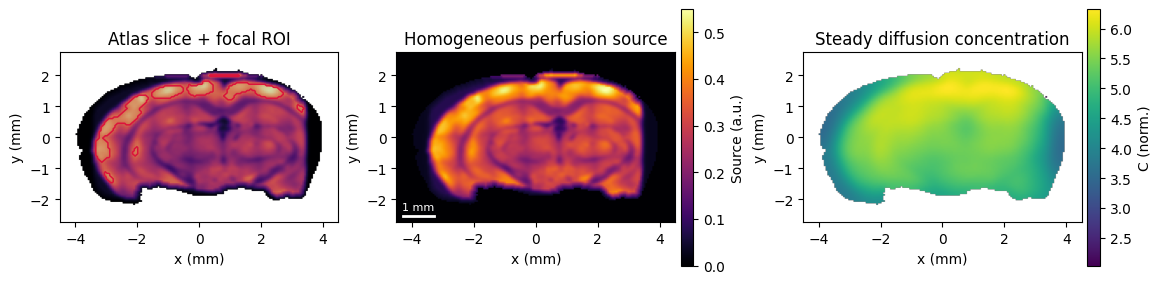

Focal mean C    : 5.8042
Off-target mean C: 5.2092
Focal/off ratio  : 1.11x


In [37]:
# Cell 4: steady diffusion solver and interactive snapshot
def _solve_steady_diffusion(source_map, brain_mask, dx_mm=0.08, D=3e-4, k_e=0.05):
    ny, nx = source_map.shape
    dx_cm = dx_mm * 0.1
    n = ny * nx
    A = lil_matrix((n, n))
    b = np.zeros(n)

    for j in range(ny):
        for i in range(nx):
            idx = j * nx + i
            if not brain_mask[j, i]:
                A[idx, idx] = 1.0
                continue
            lap_sum = 0.0
            for di, dj in ((1, 0), (-1, 0), (0, 1), (0, -1)):
                ni, nj = i + di, j + dj
                c = D / (dx_cm ** 2)
                if 0 <= ni < nx and 0 <= nj < ny and brain_mask[nj, ni]:
                    A[idx, nj * nx + ni] = c
                    lap_sum += c
            A[idx, idx] = -(lap_sum + k_e)
            b[idx] = -source_map[j, i]

    C = spsolve(csr_matrix(A), b).reshape(ny, nx)
    return np.where(brain_mask, np.clip(C, 0.0, None), np.nan)


def render_snapshot(source_peak=0.55, baseline=0.03, D=3e-4, k_e=0.05, save_path=None):
    source = baseline + (source_peak - baseline) * focal_expression
    source = np.where(brain_mask, source, 0.0)
    C = _solve_steady_diffusion(source, brain_mask, dx_mm=(x[1] - x[0]), D=D, k_e=k_e)

    fig, axes = plt.subplots(1, 3, figsize=(11.5, 3.6), constrained_layout=True)
    axes[0].imshow(brain_mask, origin='lower', extent=extent, cmap='Greys', vmin=0, vmax=1)
    axes[0].imshow(np.ma.masked_where(~brain_mask, focal_expression), origin='lower', extent=extent, cmap='magma', alpha=0.85)
    axes[0].contour(X, Y, focal_mask.astype(float), levels=[0.5], colors=['crimson'], linewidths=1.1)
    axes[0].set_title('Atlas slice + focal ROI')
    axes[0].set_xlabel('x (mm)')
    axes[0].set_ylabel('y (mm)')

    im1 = axes[1].imshow(source, origin='lower', extent=extent, cmap='inferno')
    axes[1].set_title('Homogeneous perfusion source')
    axes[1].set_xlabel('x (mm)')
    axes[1].set_ylabel('y (mm)')
    c1 = plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.02)
    c1.set_label('Source (a.u.)')

    im2 = axes[2].imshow(C, origin='lower', extent=extent, cmap='viridis')
    axes[2].set_title('Steady diffusion concentration')
    axes[2].set_xlabel('x (mm)')
    axes[2].set_ylabel('y (mm)')
    c2 = plt.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.02)
    c2.set_label('C (norm.)')

    for ax in axes:
        ax.plot([x.min() + 0.2, x.min() + 1.2], [y.min() + 0.2, y.min() + 0.2], color='white', linewidth=2.0)
        ax.text(x.min() + 0.7, y.min() + 0.32, '1 mm', color='white', ha='center', va='bottom', fontsize=8)

    if save_path is not None:
        fig.savefig(save_path, bbox_inches='tight', pad_inches=0.02)

    focal_mean = float(np.nanmean(C[focal_mask])) if np.any(focal_mask) else float('nan')
    off_mean = float(np.nanmean(C[brain_mask & (~focal_mask)])) if np.any(brain_mask & (~focal_mask)) else float('nan')
    ratio = float(focal_mean / (off_mean + 1e-12)) if np.isfinite(focal_mean) and np.isfinite(off_mean) else float('nan')

    plt.show()
    print(f'Focal mean C    : {focal_mean:.4f}')
    print(f'Off-target mean C: {off_mean:.4f}')
    print(f'Focal/off ratio  : {ratio:.2f}x')

    return {
        'figure': fig,
        'source': source,
        'concentration': C,
        'focal_mean': focal_mean,
        'off_mean': off_mean,
        'ratio': ratio,
    }


source_peak = 0.55
baseline = 0.03
diffusion_D = 3e-4
decay_ke = 0.05

default_result = render_snapshot(
    source_peak=source_peak,
    baseline=baseline,
    D=diffusion_D,
    k_e=decay_ke,
    save_path=OUT_DIR / 'CBG_panel_B_debug.svg',
)

## Export and QC

The final cell writes the notebook outputs to disk and records provenance, parameters, and quick sanity checks.

In [38]:
# Cell 6: export arrays and provenance
import datetime as dt

np.savez(
    OUT_DIR / 'CBG_panel_B_data.npz',
    source=default_result['source'],
    concentration=default_result['concentration'],
    brain_mask=brain_mask,
    focal_mask=focal_mask,
    focal_expression=focal_expression,
    x=x,
    y=y,
    dx_mm=np.array(x[1] - x[0]),
)

provenance = {
    'generated': dt.datetime.now().isoformat(),
    'source_tier': focal_payload.get('source_tier', 'unknown'),
    'paper': focal_payload.get('paper_meta', {}),
    'atlas_source': atlas_poly_meta.get('source', 'n/a'),
    'registration_bregma_mm': -2.0,
    'preprocessing_order': 'crop_black_perimeter -> fit_scale_shift_to_brain -> align_to_atlas_grid -> smooth_atlas_space -> edge_suppression',
    'grid_shape': [int(NY), int(NX)],
    'alignment_fit': {
        'mode': alignment_report.get('mode', 'unknown') if 'alignment_report' in globals() else 'unknown',
        'score': float(alignment_report.get('score', np.nan)) if 'alignment_report' in globals() else float('nan'),
        'scale_x': float(focal_payload.get('align_scale_x', 1.0)),
        'scale_y': float(focal_payload.get('align_scale_y', 1.0)),
        'shift_x_px': float(focal_payload.get('align_shift_x_px', 0.0)),
        'shift_y_px': float(focal_payload.get('align_shift_y_px', 0.0)),
    },
    'tuning': {
        'tissue_threshold_sum': float(focal_payload.get('tissue_threshold_sum', 20)),
        'crop_pad_px': int(focal_payload.get('crop_pad_px', 8)),
        'preserve_aspect': bool(focal_payload.get('preserve_aspect', True)),
        'auto_align_to_brain': bool(focal_payload.get('auto_align_to_brain', True)),
        'auto_search_shift_px': int(focal_payload.get('auto_search_shift_px', 12)),
        'auto_search_scale_offsets': list(focal_payload.get('auto_search_scale_offsets', [-0.10, 0.0, 0.10])),
        'align_scale_x': float(focal_payload.get('align_scale_x', 1.0)),
        'align_scale_y': float(focal_payload.get('align_scale_y', 1.0)),
        'align_shift_x_px': float(focal_payload.get('align_shift_x_px', 0.0)),
        'align_shift_y_px': float(focal_payload.get('align_shift_y_px', 0.0)),
        'smooth_sigma_atlas': float(focal_payload.get('smooth_sigma_atlas', 1.2)),
        'edge_exclusion_px': int(focal_payload.get('edge_exclusion_px', 5)),
        'focal_percentile': float(focal_payload.get('focal_percentile', 90)),
    },
    'parameters': {
        'D_tissue_cm2_min': float(D_tissue),
        'P_intact_cm_min': float(P_intact),
        'P_open_cm_min': float(P_open),
        'k_e_per_min': float(k_e),
        'C_blood_norm': float(C_blood),
        'source_peak': float(source_peak),
        'baseline': float(baseline),
        'D_used_cm2_min': float(diffusion_D),
        'k_e_used_per_min': float(decay_ke),
    },
    'results': {
        'brain_coverage': float(brain_mask.mean()),
        'focal_coverage_of_brain': float(coverage),
        'focal_mean_C': float(default_result['focal_mean']),
        'off_target_mean_C': float(default_result['off_mean']),
        'focal_off_ratio': float(default_result['ratio']),
    },
}

with open(OUT_DIR / 'CBG_panel_B_provenance.json', 'w') as f:
    json.dump(provenance, f, indent=2)

print('Saved outputs to:')
print(f"  {OUT_DIR / 'CBG_panel_B_data.npz'}")
print(f"  {OUT_DIR / 'CBG_panel_B_provenance.json'}")
print(f"  {OUT_DIR / 'CBG_panel_B_debug.svg'}")
print()
print('QC summary:')
print(f"  source tier             : {provenance['source_tier']}")
print(f"  focal coverage of brain : {provenance['results']['focal_coverage_of_brain']:.3%}")
print(f"  focal/off ratio         : {provenance['results']['focal_off_ratio']:.2f}x")
print(f"  alignment mode          : {provenance['alignment_fit']['mode']}")
print(f"  alignment score         : {provenance['alignment_fit']['score']:.4f}")
print(f"  grid shape              : {tuple(provenance['grid_shape'])}")

Saved outputs to:
  CBG_panel_B_outputs/CBG_panel_B_data.npz
  CBG_panel_B_outputs/CBG_panel_B_provenance.json
  CBG_panel_B_outputs/CBG_panel_B_debug.svg

QC summary:
  source tier             : pdf-panel-e
  focal coverage of brain : 8.522%
  focal/off ratio         : 1.11x
  alignment mode          : auto
  alignment score         : 0.8617
  grid shape              : (110, 160)
